<div style="background-color: #f9f9f9; padding: 20px; border-left: 6px solid #2e86de; border-radius: 5px; font-family: sans-serif;">
    <h2 style="color: #2e86de; margin-top: 0;">📍 Содержание проекта</h2>
    <ul style="list-style-type: none; padding-left: 0; line-height: 1.8;">
        <li><a href="#intro" style="text-decoration: none; color: #34495e; font-weight: bold;">1. Введение и цели проекта</a> — <small>контекст исследования</small></li>
        <li><a href="#libraries" style="text-decoration: none; color: #34495e; font-weight: bold;">2. Импорт библиотек</a> — <small>техническое окружение</small></li>
        <li><a href="#data_loading" style="text-decoration: none; color: #34495e; font-weight: bold;">3. Загрузка и подготовка данных</a> — <small>импорт датасета, анализ структуры и очистка от дубликатов</small></li>        
        <li><a href="#features" style="text-decoration: none; color: #34495e; font-weight: bold;">4. Feature Engineering</a> — <small>создание признака distance_to_center и кодирование</small></li>
        <li><a href="#linear_reg" style="text-decoration: none; color: #34495e; font-weight: bold;">5. Обучение модели (Linear Regression)</a> — <small>масштабирование и тренировка</small></li>
        <li><a href="#results" style="text-decoration: none; color: #34495e; font-weight: bold;">6. Оценка результатов</a> — <small>сравнение реальных и предсказанных цен</small></li>
    </ul>
</div>

<a id='intro'></a>
# 1. Введение и цели проекта

**Цель проекта:** Разработка модели машинного обучения для автоматизированной оценки стоимости жилой недвижимости в г. Астана. 

В рамках работы решаются следующие задачи:
* Сбор и дополнение данных с помощью веб-парсинга (BeautifulSoup).
* Глубокая предобработка данных: удаление дубликатов, некорректных значений и заполнение пропусков.
* Генерация новых признаков (расстояние до центра города, тип дома, район).
* Построение и валидация прогнозной модели на базе линейной регрессии.

<a id='libraries'></a>
# 2. Импорт необходимых библиотек для работы с данными и ML

In [5]:
%pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.1 MB/s  0:00:002.5 MB/s eta 0:00:01:01
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install seaborn plotly pandas matplotlib numpy scipy scikit-learn jupyterlab


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from geopy.distance import geodesic
from IPython.display import display, Image
import warnings
from datetime import datetime
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

pd.options.display.float_format = '{:.2f}'.format

<a id='data_loading'></a>
# 3. Загрузка и подготовка данных

На данном этапе мы загружаем сырые данные, полученные в результате парсинга сайта Krisha.kz, и проводим их первичный аудит.

**Основные шаги:**
* **Загрузка данных:** Чтение CSV-файла и проверка размерности.
* **Анализ структуры:** Проверка типов данных и поиск пропущенных значений.
* **Очистка:** Удаление дубликатов и строк с критическими пропусками, которые невозможно восстановить.

In [3]:
df = pd.read_csv('data/krisha_astana_processed_1500.csv')
print(f"Колиество квартир после парсинга с сайта krisha.kz по Астане: {len(df)}")
df.head()


Колиество квартир после парсинга с сайта krisha.kz по Астане: 29943


,name,information,address,price,owner,complex_name,house_type,in_pledge,construction_year,ceiling_height,...,condition,area,room_count,floor,floor_count,floor,district,url,lat,lon
0,2-комнатная квартира · 70.38 м²,"жил. комплекс MOD Ultra, 17 этажей, 2026 г.п.,...",Хусейн бен Талал 37,73406340.00,Новостройка,mod ultra,NaN,False,2026,3.00,...,NaN,70.38,2.00,NaN,NaN,NaN,Есильский р-н,https://krisha.kz/a/show/1005837203?srchid=019...,51.08,71.43
1,2-комнатная квартира · 65.97 м²,"жил. комплекс GreenLine. Garden, 16 этажей, 20...",Е-899 7,57657780.00,Новостройка,greenline. garden,NaN,False,2026,3.00,...,NaN,65.97,2.00,NaN,NaN,NaN,Нура р-н,https://krisha.kz/a/show/761098327?srchid=019b...,51.14,71.39
2,2-комнатная квартира · 48.02 м²,"жил. комплекс UIA.DARYN, 17 этажей, 2026 г.п.,...",Улы Дала 14,36879360.00,Новостройка,uia.daryn,NaN,False,2026,2.65,...,NaN,48.02,2.00,NaN,NaN,NaN,Нура р-н,https://krisha.kz/a/show/1008911410?srchid=019...,51.10,71.36
3,1-комнатная квартира · 27.4 м²,"жил. комплекс Астана, 3 этажа, 2022 г.п., пото...",мкр Уркер Укили Ыбырай 15,7946000.00,Новостройка,астана,NaN,False,2022,2.70,...,NaN,27.40,1.00,NaN,NaN,NaN,Нура р-н,https://krisha.kz/a/show/48623111?srchid=019bf...,51.12,71.25
4,3-комнатная квартира · 87 м² · 6/10 этаж,"жил. комплекс Нур Канат, монолитный дом, 2012 ...",А. Бокейханова 8,48000000.00,Риелтор,нур канат,монолитный дом,False,2012,3.00,...,NaN,87.00,3.00,6.00,10.00,6.00,Есильский р-н,https://krisha.kz/a/show/1008684541?srchid=019...,51.12,71.44


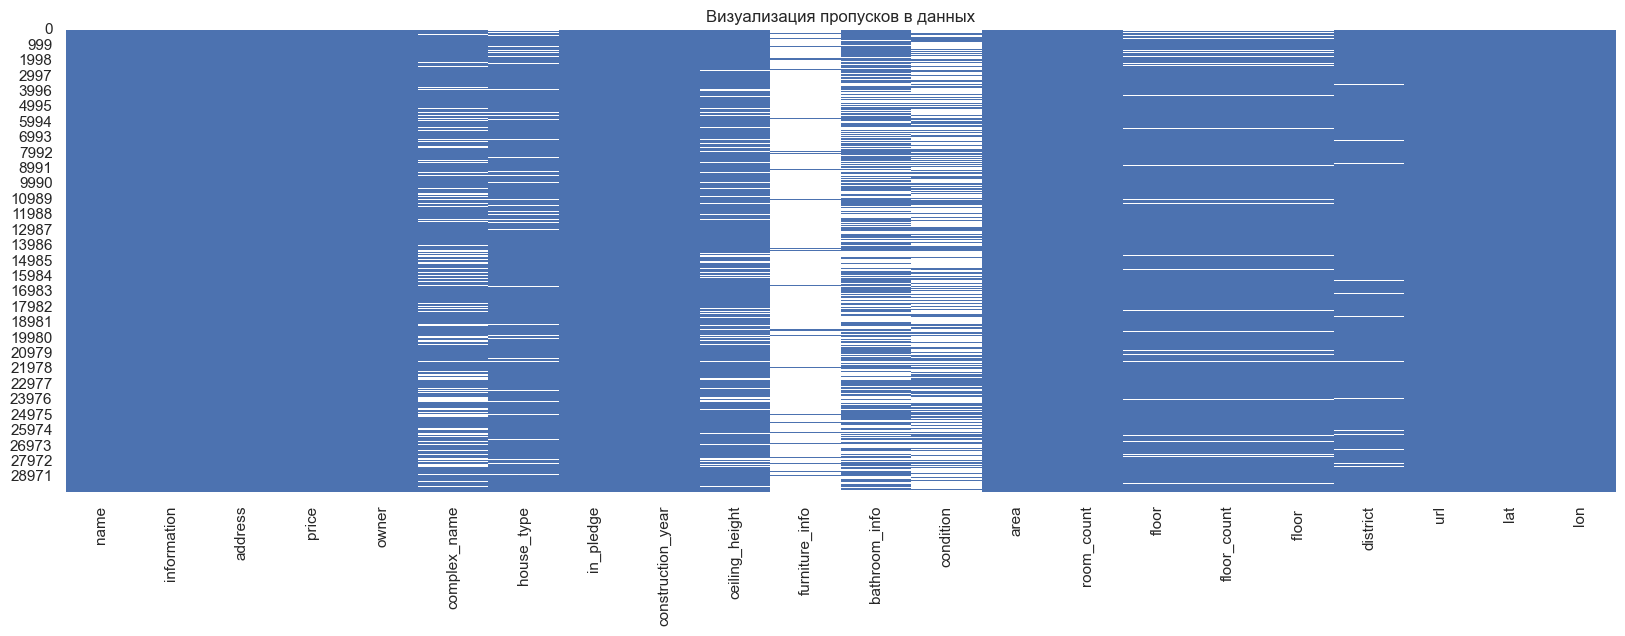

In [4]:
plt.figure(figsize=(20, 6))

sns.heatmap(
    df.isnull(),
    cmap=[ "#4c72b0", "#ffffff"],
    cbar=False
)

plt.title("Визуализация пропусков в данных")
plt.show()


In [5]:
df = df.drop(['furniture_info', 'condition', 'complex_name', 'floor', 'bathroom_info'], axis=1)

In [30]:
df['owner'].unique()

array(['Новостройка', 'Риелтор', 'Хозяин недвижимости', 'Неизвестно'],
      dtype=object)

In [6]:
df = df[df['owner'] != 'Неизвестно']

print(f"Строк осталось после удаления: {len(df)}")

Строк осталось после удаления: 29743


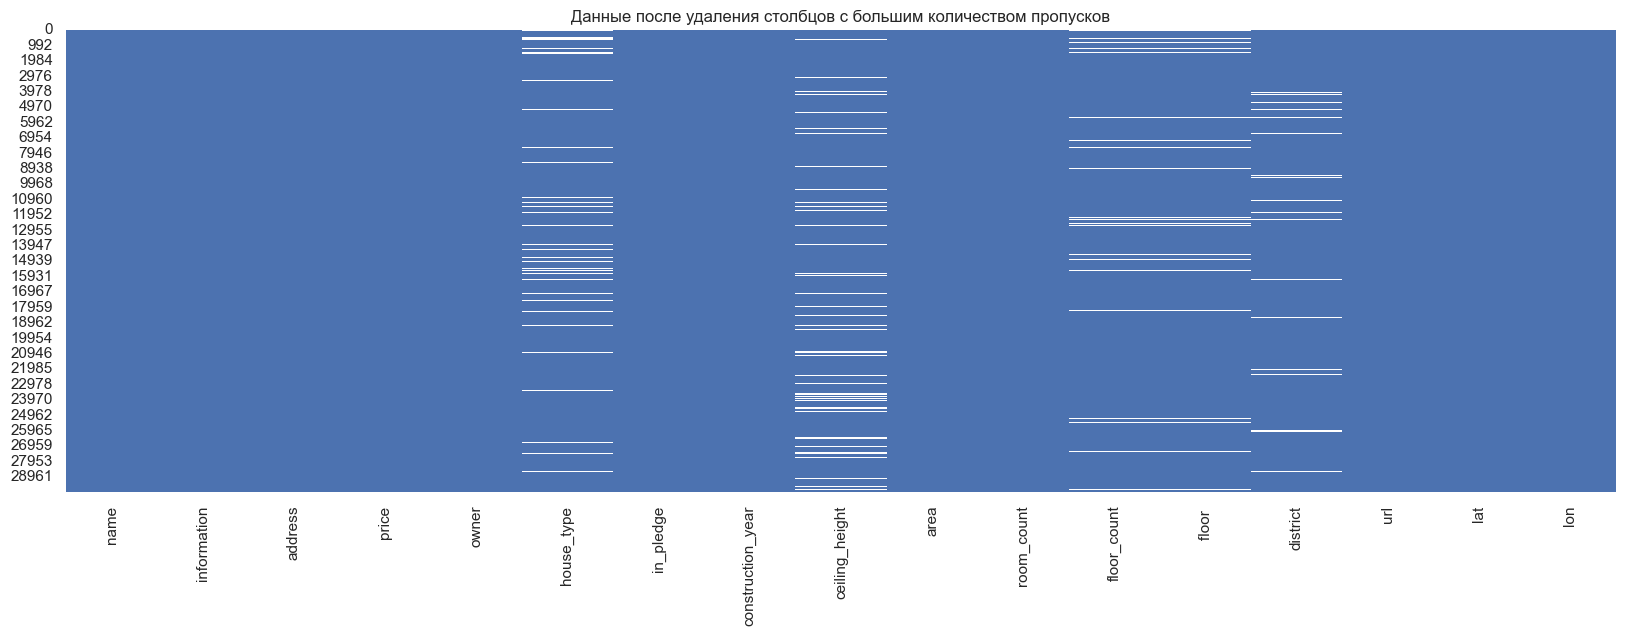

In [7]:
plt.figure(figsize=(20, 6))

sns.heatmap(
    df.isnull(),
    cmap=[ "#4c72b0", "#ffffff"],
    cbar=False
)

plt.title("Данные после удаления столбцов с большим количеством пропусков")
plt.show()


### Удаление дубликатов

In [8]:
key_features = ['price', 'area', 'room_count', 'floor ', 'floor_count', 'lat', 'lon']

df = df.drop_duplicates(subset=key_features).reset_index(drop=True)

print(f"Найдено строк-дубликатов (с учетом owner): {len(df)}")

Найдено строк-дубликатов (с учетом owner): 23479


### Удаление аномалий согласно цене и площади
#### Определение аномалий

In [9]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['price'],
    mode='lines',
    line_shape='hv',
    name='Цена',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Цена: %{y:,.1f} тг<extra></extra>'
))

# Сами определяем, какие числа подписывать на оси Y
# Для площади это обычно от 1 до 2000-3000
tick_values = [5000000, 7000000, 10000000, 30000000, 50000000, 70000000, 90000000, 110000000, 150000000]

fig.update_layout(
    title='Интерактивный пульс цен (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Цена',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    width = 1000,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для площади
price_stats = df['price'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print(f"Всего объектов:    {int(price_stats['count']):,}")
print(f"Минимум:           {price_stats['min']:.1f} м²")
print(f"1% (Микро):        {price_stats['1%']:.1f} м²")
print(f"5% (Компактные):   {price_stats['5%']:.1f} м²")
print(f"Медиана (Центр):   {price_stats['50%']:.1f} м²")
print(f"95% (Огромные):    {price_stats['95%']:.1f} м²")
print(f"99% (Гиганты):     {price_stats['99%']:.1f} м²")
print(f"Максимум:          {price_stats['max']:.1f} м²")
print("-" * 45)

top_areas = df['price'].value_counts().head(5)

print("\n--- ТОП-5 ---")
for price, count in top_areas.items():
    print(f"{price:.1f} тг встречается {count} раз(а)")

Всего объектов:    23,479
Минимум:           3700000.0 м²
1% (Микро):        11500000.0 м²
5% (Компактные):   17000000.0 м²
Медиана (Центр):   36000000.0 м²
95% (Огромные):    120000000.0 м²
99% (Гиганты):     225492562.4 м²
Максимум:          1900000000.0 м²
---------------------------------------------

--- ТОП-5 ---
35000000.0 тг встречается 410 раз(а)
30000000.0 тг встречается 389 раз(а)
25000000.0 тг встречается 376 раз(а)
45000000.0 тг встречается 352 раз(а)
40000000.0 тг встречается 327 раз(а)


In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['construction_year'],
    mode='lines',
    line_shape='hv',
    name='Год постройки',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Год постройки: %{y:,.1f} г<extra></extra>'
))

tick_values = [1960, 1970, 1990, 2000, 2020, 2026, 2030]

fig.update_layout(
    title='Интерактивный пульс года постройки (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Год постройки',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для площади
price_stats = df['construction_year'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print(f"Всего объектов:    {int(price_stats['count']):,}")
print(f"Минимум:           {price_stats['min']:.1f}")
print(f"1% (Микро):        {price_stats['1%']:.1f}")
print(f"5% (Компактные):   {price_stats['5%']:.1f}")
print(f"Медиана (Центр):   {price_stats['50%']:.1f}")
print(f"95% (Огромные):    {price_stats['95%']:.1f}")
print(f"99% (Гиганты):     {price_stats['99%']:.1f}")
print(f"Максимум:          {price_stats['max']:.1f}")
print("-" * 45)

top_areas = df['construction_year'].value_counts().head(5)

print("\n--- ТОП-5 ---")
for price, count in top_areas.items():
    print(f"{price:.1f} г встречается {count} раз(а)")


Всего объектов:    23,479
Минимум:           1860.0
1% (Микро):        1971.0
5% (Компактные):   1997.0
Медиана (Центр):   2021.0
95% (Огромные):    2026.0
99% (Гиганты):     2026.0
Максимум:          2029.0
---------------------------------------------

--- ТОП-5 ---
2025.0 г встречается 3714 раз(а)
2026.0 г встречается 1901 раз(а)
2024.0 г встречается 1856 раз(а)
2021.0 г встречается 1806 раз(а)
2020.0 г встречается 1720 раз(а)


In [11]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['ceiling_height'],
    mode='lines',
    line_shape='hv',
    name='Высота потолков',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Высота потолков: %{y:,.1f} м<extra></extra>'
))

tick_values = [2, 2.5, 3.7, 2.8, 3, 4, 5, 6]

fig.update_layout(
    title='Интерактивный пульс высоты потолков (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Высота потолков (м)',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для высоты потолков
ceiling_stats = df['ceiling_height'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print("--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ВЫСОТЫ ПОТОЛКОВ ---")
print(f"Всего объявлений:  {int(ceiling_stats['count']):,}")
print(f"Минимум:           {ceiling_stats['min']:.2f} м")
print(f"1% (Самые низкие): {ceiling_stats['1%']:.2f} м")
print(f"5% (Стандарт):     {ceiling_stats['5%']:.2f} м")
print(f"Медиана (Центр):   {ceiling_stats['50%']:.2f} м")
print(f"95% (Высокие):     {ceiling_stats['95%']:.2f} м")
print(f"99% (Дворцы/Ошибки): {ceiling_stats['99%']:.2f} м")
print(f"Максимум:          {ceiling_stats['max']:.2f} м")
print("-" * 45)

# 2. Самые часто встречающиеся высоты
top_ceilings = df['ceiling_height'].value_counts().head(5)

print("\n--- ТОП-5 ---")
for height, count in top_ceilings.items():
    print(f"{height:.2f} м встречается {count} раз(а)")

--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ВЫСОТЫ ПОТОЛКОВ ---
Всего объявлений:  21,393
Минимум:           2.00 м
1% (Самые низкие): 2.50 м
5% (Стандарт):     2.70 м
Медиана (Центр):   3.00 м
95% (Высокие):     3.10 м
99% (Дворцы/Ошибки): 3.30 м
Максимум:          6.30 м
---------------------------------------------

--- ТОП-5 ---
3.00 м встречается 10359 раз(а)
2.70 м встречается 6680 раз(а)
2.80 м встречается 1630 раз(а)
3.30 м встречается 558 раз(а)
2.50 м встречается 432 раз(а)


In [15]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['area'],
    mode='lines',
    line_shape='hv',
    name='Площадь',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Площадь: %{y:,.1f} кв.м<extra></extra>'
))

tick_values = [10, 20, 50, 100, 200, 500, 900]

fig.update_layout(
    title='Интерактивный пульс площади (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Площадь (м²)',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для площади
area_stats = df['area'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print("--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ПЛОЩАДЕЙ ---")
print(f"Всего объектов:    {int(area_stats['count']):,}")
print(f"Минимум:           {area_stats['min']:.1f} м²")
print(f"1% (Микро):        {area_stats['1%']:.1f} м²")
print(f"5% (Компактные):   {area_stats['5%']:.1f} м²")
print(f"Медиана (Центр):   {area_stats['50%']:.1f} м²")
print(f"95% (Огромные):    {area_stats['95%']:.1f} м²")
print(f"99% (Гиганты):     {area_stats['99%']:.1f} м²")
print(f"Максимум:          {area_stats['max']:.1f} м²")
print("-" * 45)

# 2. Самые часто встречающиеся площади
top_areas = df['area'].value_counts().head(5)

print("\n--- ТОП-5 ---")
for area, count in top_areas.items():
    print(f"{area:.1f} м² встречается {count} раз(а)")

--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ПЛОЩАДЕЙ ---
Всего объектов:    23,562
Минимум:           3.3 м²
1% (Микро):        22.0 м²
5% (Компактные):   34.1 м²
Медиана (Центр):   62.0 м²
95% (Огромные):    141.0 м²
99% (Гиганты):     217.0 м²
Максимум:          866.0 м²
---------------------------------------------

--- ТОП-5 ---
40.0 м² встречается 580 раз(а)
60.0 м² встречается 483 раз(а)
38.0 м² встречается 410 раз(а)
42.0 м² встречается 398 раз(а)
70.0 м² встречается 397 раз(а)


In [12]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['room_count'],
    mode='lines',
    line_shape='hv',
    name='Количество комнат',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Количество комнат: %{y:,.1f} <extra></extra>'
))

tick_values = [1, 2, 3, 4, 5, 6, 10]

fig.update_layout(
    title='Интерактивный пульс количества комнат (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Количество комнат',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для количества комнат
room_stats = df['room_count'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print("--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ КОЛИЧЕСТВА КОМНАТ ---")
print(f"Всего объектов:     {int(room_stats['count']):,}")
print(f"Минимум:            {room_stats['min']:.0f}")
print(f"1% (Студии/Мало):   {room_stats['1%']:.0f}")
print(f"Медиана (Центр):    {room_stats['50%']:.0f}")
print(f"95% (Многокомнат):  {room_stats['95%']:.0f}")
print(f"99% (Эксклюзив):    {room_stats['99%']:.0f}")
print(f"Максимум:           {room_stats['max']:.0f}")
print("-" * 45)

# 2. Самые часто встречающиеся варианты
top_rooms = df['room_count'].value_counts().head(5)

print("\n--- ТОП-5 ---")
for rooms, count in top_rooms.items():
    print(f"{rooms:.0f}-комнатные встречаются {count} раз(а)")

--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ КОЛИЧЕСТВА КОМНАТ ---
Всего объектов:     23,479
Минимум:            1
1% (Студии/Мало):   1
Медиана (Центр):    2
95% (Многокомнат):  4
99% (Эксклюзив):    5
Максимум:           17
---------------------------------------------

--- ТОП-5 ---
2-комнатные встречаются 8730 раз(а)
3-комнатные встречаются 6614 раз(а)
1-комнатные встречаются 5584 раз(а)
4-комнатные встречаются 2126 раз(а)
5-комнатные встречаются 302 раз(а)


In [14]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['floor '],
    mode='lines',
    line_shape='hv',
    name='Этаж',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Этаж: %{y:,.1f} <extra></extra>'
))

tick_values = [1, 10, 20, 30]

fig.update_layout(
    title='Интерактивный пульс этажей  (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Этаж',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для этажей
floor_stats = df['floor '].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print("--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ЭТАЖНОСТИ ---")
print(f"Всего объектов:    {int(floor_stats['count']):,}")
print(f"Минимум:           {floor_stats['min']:.0f}")
print(f"1% (Низкие):       {floor_stats['1%']:.0f}")
print(f"Медиана (50%):     {floor_stats['50%']:.0f}")
print(f"95% (Высотки):     {floor_stats['95%']:.0f}")
print(f"99% (Пентхаусы):   {floor_stats['99%']:.0f}")
print(f"Максимум:          {floor_stats['max']:.0f}")
print("-" * 45)

# 2. Самые часто встречающиеся этажи
top_floors = df['floor '].value_counts().head(5)

print("\n--- ТОП-5 ---")
for floor, count in top_floors.items():
    print(f"{int(floor)}-й этаж встречается {count} раз(а)")

--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ЭТАЖНОСТИ ---
Всего объектов:    21,992
Минимум:           1
1% (Низкие):       1
Медиана (50%):     6
95% (Высотки):     15
99% (Пентхаусы):   20
Максимум:          42
---------------------------------------------

--- ТОП-5 ---
2-й этаж встречается 2343 раз(а)
5-й этаж встречается 2281 раз(а)
3-й этаж встречается 2197 раз(а)
4-й этаж встречается 2183 раз(а)
6-й этаж встречается 1882 раз(а)


In [15]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(df))), 
    y=df['floor_count'],
    mode='lines',
    line_shape='hv',
    name='Этажность дома',
    line=dict(color='royalblue', width=1),
    hovertemplate='Индекс: %{x}<br>Этажность дома: %{y:,.1f} <extra></extra>'
))

tick_values = [1, 10, 20, 30]

fig.update_layout(
    title='Интерактивный пульс этажности дома  (Чистая ось Y)',
    xaxis_title='Порядковый номер (индекс)',
    yaxis_title='Этажность дома',
    yaxis_type="log",
    template='plotly_white',
    height=600,
    hovermode='x unified',
    margin=dict(l=100) 
)

fig.update_yaxes(
    tickmode='array',
    tickvals=tick_values, # Какие значения подписывать
    gridcolor='lightgray' # Сетка станет понятнее
)

fig.show()

# 1. Считаем статистику для общей этажности домов
floor_count_stats = df['floor_count'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

print("--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ЭТАЖНОСТИ ДОМОВ ---")
print(f"Всего объектов:    {int(floor_count_stats['count']):,}")
print(f"Минимум:           {floor_count_stats['min']:.0f}")
print(f"1% (Малоэтажки):   {floor_count_stats['1%']:.0f}")
print(f"Медиана (50%):     {floor_count_stats['50%']:.0f}")
print(f"95% (Высотки):     {floor_count_stats['95%']:.0f}")
print(f"99% (Небоскребы):  {floor_count_stats['99%']:.0f}")
print(f"Максимум:          {floor_count_stats['max']:.0f}")
print("-" * 45)

# 2. Самые часто встречающиеся типы домов по этажности
top_house_floors = df['floor_count'].value_counts().head(5)

print("\n--- ТОП-5 ---")
for floors, count in top_house_floors.items():
    print(f"{int(floors)}-этажные дома встречаются {count} раз(а)")

--- СТАТИСТИЧЕСКИЙ ПОРТРЕТ ЭТАЖНОСТИ ДОМОВ ---
Всего объектов:    21,992
Минимум:           1
1% (Малоэтажки):   4
Медиана (50%):     10
95% (Высотки):     21
99% (Небоскребы):  25
Максимум:          90
---------------------------------------------

--- ТОП-5 ---
9-этажные дома встречаются 5591 раз(а)
12-этажные дома встречаются 3565 раз(а)
10-этажные дома встречаются 1767 раз(а)
5-этажные дома встречаются 1542 раз(а)
14-этажные дома встречаются 1027 раз(а)


In [16]:
def clean_real_estate_data(data, config):
    """
    data: твой df_clean, который ты передашь на вход
    config: словарь с границами
    """
    
    # 1. Удаляем явный бред (несоответствие комнат и площади)
    if 'area' in data.columns and 'room_count' in data.columns:
        initial_count = len(data)
        # Логика: если 2+ комнаты, но площадь подозрительно мала (< 20 м) — удаляем
        bad_area_mask = (data['room_count'] >= 2) & (data['area'] < 20)
        data = data[~bad_area_mask]
        print(f"Логика (комнаты/площадь): удалено {initial_count - len(data)} строк")

    # 2. Фильтрация по твоим границам из конфига
    for column, (min_val, max_val) in config.items():
        if column in data.columns:
            initial_count = len(data)
            data = data[
                (data[column] >= min_val) & 
                (data[column] <= max_val) | 
                (data[column].isnull()) # <- Добавляем сохранение NaN
]
            print(f"Фильтр {column}: удалено {initial_count - len(data)} строк")
            
    # 3. Проверка на этажность (нельзя жить выше крыши)
    if 'floor' in data.columns and 'floor_count' in data.columns:
        initial_count = len(data)
        data = data[data['floor'] <= data['floor_count']]
        print(f"Логика (этаж <= этажность дома): удалено {initial_count - len(data)} строк")
        
    return data

cleaning_config = {
    'price':             (7_000_000, 200_000_000),
    'construction_year': (1960, 2026),
    'ceiling_height':    (2.5, 4.0),
    'area':              (15, 300),
    'room_count':        (1, 7),
    'floor':             (1, 27),
    'floor_count':       (1, 27)
}

df_cleaned = clean_real_estate_data(df, cleaning_config)
print(f"Итого строк: {len(df_cleaned)}")

Логика (комнаты/площадь): удалено 2 строк
Фильтр price: удалено 318 строк
Фильтр construction_year: удалено 76 строк
Фильтр ceiling_height: удалено 42 строк
Фильтр area: удалено 26 строк
Фильтр room_count: удалено 2 строк
Фильтр floor_count: удалено 162 строк
Итого строк: 22851


In [17]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22851 entries, 0 to 23478
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               22851 non-null  object 
 1   information        22851 non-null  object 
 2   address            22825 non-null  object 
 3   price              22851 non-null  float64
 4   owner              22851 non-null  object 
 5   house_type         21042 non-null  object 
 6   in_pledge          22851 non-null  bool   
 7   construction_year  22851 non-null  int64  
 8   ceiling_height     20831 non-null  float64
 9   area               22851 non-null  float64
 10  room_count         22851 non-null  float64
 11  floor_count        21436 non-null  float64
 12  floor              21436 non-null  float64
 13  district           21803 non-null  object 
 14  url                22851 non-null  object 
 15  lat                22851 non-null  float64
 16  lon                22851 no

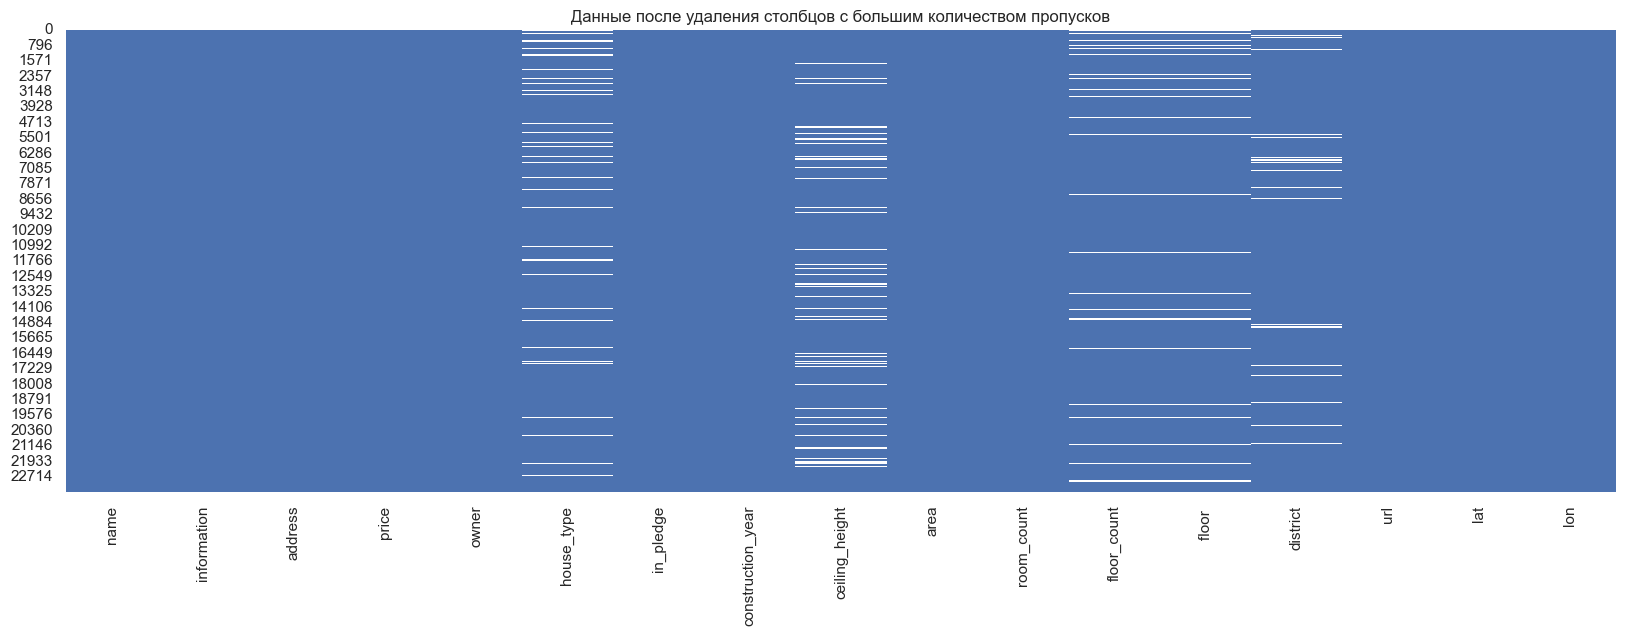

In [18]:
plt.figure(figsize=(20, 6))

sns.heatmap(
    df_cleaned.isnull(),
    cmap=[ "#4c72b0", "#ffffff"],
    cbar=False
)

plt.title("Данные после удаления столбцов с большим количеством пропусков")
plt.show()


In [41]:
df_cleaned.isnull().sum()

name                    0
information             0
address                26
price                   0
owner                   0
house_type           1572
in_pledge               0
construction_year       0
ceiling_height       1580
area                    0
room_count              0
floor_count          1335
floor                1335
district              981
url                     0
lat                     0
lon                     0
dtype: int64

In [20]:
missing_district = df_cleaned[df_cleaned['district'].isnull()]
known_district = df_cleaned[df_cleaned['district'].notnull()]

print(f"Строк без района: {len(missing_district)}")
print(f"Строк с известным районом: {len(known_district)}")

def fill_district_by_distance(row, known_data):
    
    distances = np.sqrt(
        (known_data['lat'] - row['lat'])**2 + 
        (known_data['lon'] - row['lon'])**2
    )

    closest_index = distances.idxmin()
    
    return known_data.loc[closest_index, 'district']

# 4. Заполняем пропуски
if len(missing_district) > 0:
    df_cleaned.loc[df_cleaned['district'].isnull(), 'district'] = missing_district.apply(
        lambda row: fill_district_by_distance(row, known_district), axis=1
    )
    print("Пропуски в 'district' заполнены.")
else:
    print("Пропусков в 'district' нет.")

# 5. Проверка
print(df_cleaned['district'].isnull().sum())

Строк без района: 1048
Строк с известным районом: 21803
Пропуски в 'district' заполнены.
0


In [22]:
def fill_ceiling_height_by_location(df, k=5):
    """
    Заполняет пропуски в 'ceiling_height', усредняя высоту 
    k ближайших соседей по координатам.
    """
    # 1. Разделяем на данные с пропусками и без
    missing_height = df[df['ceiling_height'].isnull()]
    known_height = df[df['ceiling_height'].notnull()]

    print(f"Строк без высоты потолков: {len(missing_height)}")
    print(f"Строк с известной высотой: {len(known_height)}")

    # 2. Функция для поиска соседей и усреднения
    def get_mean_neighbor_height(row, known_data, k_neighbors):
        # Евклидово расстояние
        distances = np.sqrt(
            (known_data['lat'] - row['lat'])**2 + 
            (known_data['lon'] - row['lon'])**2
        )
        
        # Находим индексы k ближайших соседей
        closest_indices = distances.nsmallest(k_neighbors).index
        
        # Берём среднее значение их потолков
        return known_data.loc[closest_indices, 'ceiling_height'].mean()

    # 3. Применяем функцию для заполнения
    df.loc[df['ceiling_height'].isnull(), 'ceiling_height'] = missing_height.apply(
        lambda row: get_mean_neighbor_height(row, known_height, k), axis=1
    )
    
    print("Пропуски в 'ceiling_height' заполнены (K-NN усреднение).")
    return df

# --- Применяем функцию ---
df_cleaned = fill_ceiling_height_by_location(df_cleaned)

# 4. Проверка
print(f"Пропусков осталось: {df_cleaned['ceiling_height'].isnull().sum()}")

Строк без высоты потолков: 2020
Строк с известной высотой: 20831
Пропуски в 'ceiling_height' заполнены (K-NN усреднение).
Пропусков осталось: 0


In [24]:
from scipy.stats import mode

def fill_house_type_by_location_year(df, k=5):
    """
    Заполняет пропуски в 'house_type', используя моду (самый частый тип) 
    среди k ближайших соседей по координатам и году постройки.
    """
    # 1. Разделяем на данные с пропусками и без
    missing_type = df[df['house_type'].isnull()]
    known_type = df[df['house_type'].notnull()]

    print(f"Строк без типа дома: {len(missing_type)}")
    print(f"Строк с известным типом: {len(known_type)}")

    # 2. Функция для поиска соседей и определения моды
    def get_most_common_neighbor_type(row, known_data, k_neighbors):
        # Евклидово расстояние (с учетом года постройки для точности)
        # Примечание: года могут иметь разный масштаб, но для локального поиска
        # в рамках одного района это допустимо.
        distances = np.sqrt(
            (known_data['lat'] - row['lat'])**2 + 
            (known_data['lon'] - row['lon'])**2 +
            ((known_data['construction_year'] - row['construction_year']) / 100)**2 # Масштабируем год
        )
        
        # Находим индексы k ближайших соседей
        closest_indices = distances.nsmallest(k_neighbors).index
        
        # Берём моду (самое частое значение) типов домов соседей
        types = known_data.loc[closest_indices, 'house_type']
        most_common = types.mode()[0] # mode() возвращает Series
        
        return most_common

    # 3. Применяем функцию для заполнения
    df.loc[df['house_type'].isnull(), 'house_type'] = missing_type.apply(
        lambda row: get_most_common_neighbor_type(row, known_type, k), axis=1
    )
    
    print("Пропуски в 'house_type' заполнены (K-NN мода).")
    return df

# --- Применяем функцию ---
df_cleaned = fill_house_type_by_location_year(df_cleaned)

# 4. Проверка
print(f"Пропусков осталось: {df_cleaned['house_type'].isnull().sum()}")

Строк без типа дома: 1809
Строк с известным типом: 21042
Пропуски в 'house_type' заполнены (K-NN мода).
Пропусков осталось: 0


In [28]:
def fill_floor_count_by_location_year_type(df, k=5):
    """
    Заполняет пропуски в 'floor_count', усредняя значения
    k ближайших соседей по координатам, году и типу дома.
    """
    
    # 1. Разделяем на данные с пропусками и без
    missing_floors = df[df['floor_count'].isnull()]
    known_floors = df[df['floor_count'].notnull()]

    print(f"Строк с пропусками в 'floor_count': {len(missing_floors)}")
    print(f"Строк с известной этажностью: {len(known_floors)}")

    # 2. Функция для поиска соседей и усреднения
    def get_mean_neighbor_floor_count(row, known_data, k_neighbors):
        # Евклидово расстояние (с учетом года и типа дома)
        type_match = (known_data['house_type'] == row['house_type']).astype(int)
        
        distances = np.sqrt(
            (known_data['lat'] - row['lat'])**2 + 
            (known_data['lon'] - row['lon'])**2 +
            ((known_data['construction_year'] - row['construction_year']) / 100)**2 +
            (1 - type_match) # Увеличиваем расстояние, если тип дома отличается
        )
        
        # Находим индексы k ближайших соседей
        closest_indices = distances.nsmallest(k_neighbors).index
        
        # Берём среднее значение этажности соседей
        mean_floors = known_data.loc[closest_indices, 'floor_count'].mean()
        
        return mean_floors

    # 3. Применяем функцию для заполнения
    # Сначала считаем новые значения, затем присваиваем их
    new_values = missing_floors.apply(
        lambda row: get_mean_neighbor_floor_count(row, known_floors, k), axis=1
    )
    
    # Округляем до целых чисел, так как этажи не могут быть дробными
    df.loc[df['floor_count'].isnull(), 'floor_count'] = new_values.round().astype(int)
    
    print("Пропуски в 'floor_count' заполнены (K-NN усреднение).")
    return df

# --- Применяем функцию ---
df_cleaned = fill_floor_count_by_location_year_type(df_cleaned)

# 4. Проверка
print(f"Пропусков в 'floor_count': {df_cleaned['floor_count'].isnull().sum()}")

Строк с пропусками в 'floor_count': 1415
Строк с известной этажностью: 21436
Пропуски в 'floor_count' заполнены (K-NN усреднение).
Пропусков в 'floor_count': 0


In [29]:
import re

def extract_floor_from_text(text):
    if not isinstance(text, str):
        return None
    
    # 1. Ищем шаблон "число / число" (например, 5/9)
    match_slash = re.search(r'(\d+)\s*/\s*\d+', text)
    if match_slash:
        return int(match_slash.group(1))
    
    # 2. Ищем шаблон "число этаж" (например, "этаж 5" или "5 этаж")
    match_floor = re.search(r'(\d+)\s*этаж', text)
    if match_floor:
        return int(match_floor.group(1))                
    
    return None

# --- Применяем regex ---
# Создаем временную колонку с данными из текста
df_cleaned['floor_from_text'] = df_cleaned['information'].apply(extract_floor_from_text)

# --- Объединяем с существующей колонкой 'floor ' ---
# Заполняем пропуски в 'floor ' данными из текста, если они нашлись
df_cleaned['floor '] = df_cleaned['floor '].fillna(df_cleaned['floor_from_text'])

# Удаляем временную колонку
df_cleaned = df_cleaned.drop(columns=['floor_from_text'])

# --- Проверка ---
print(f"Пропусков в 'floor ': {df_cleaned['floor '].isnull().sum()}")

Пропусков в 'floor ': 996


In [30]:
import requests
from bs4 import BeautifulSoup
import time

# Функция для парсинга одной страницы
def parse_floor_from_url(url):
    try:
        # 1. Скачиваем страницу (добавь user-agent, чтобы выглядеть как браузер)
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=10)
        
        if response.status_code != 200:
            return None
        
        # 2. Парсим HTML
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # 3. Ищем элемент по классу и data-name
        floor_element = soup.find('div', {'class': 'offer__info-item', 'data-name': 'flat.floor'})
        
        if floor_element:
            # Текст обычно выглядит как "5 этаж из 9" или "5"
            text = floor_element.get_text(strip=True)
            # Достаем первое число (этаж)
            floor_match = re.search(r'(\d+)', text)
            if floor_match:
                return int(floor_match.group(1))
                
        return None
        
    except Exception as e:
        print(f"Ошибка при парсинге {url}: {e}")
        return None

# --- Применяем к датафрейму ---
# Берем только те строки, где floor все еще None
mask = df_cleaned['floor '].isnull()
urls_to_parse = df_cleaned.loc[mask, 'url']

print(f"Всего квартир для парсинга: {len(urls_to_parse)}")

# Парсим с задержкой, чтобы не заблокировали
for index, url in urls_to_parse.items():
    print(f"Парсинг {index}... ")
    floor = parse_floor_from_url(url)
    if floor:
        df_cleaned.loc[index, 'floor '] = floor
    time.sleep(1) # Задержка 1 секунда

print("Парсинг завершен.")
print(f"Пропусков в 'floor ' осталось: {df_cleaned['floor '].isnull().sum()}")

Всего квартир для парсинга: 996
Парсинг 59... 
Парсинг 108... 
Парсинг 185... 
Парсинг 244... 
Парсинг 261... 
Парсинг 322... 
Парсинг 323... 
Парсинг 392... 
Парсинг 536... 
Парсинг 637... 
Парсинг 654... 
Парсинг 702... 
Парсинг 710... 
Парсинг 713... 
Парсинг 730... 
Парсинг 736... 
Парсинг 784... 
Парсинг 808... 
Парсинг 843... 
Парсинг 857... 
Парсинг 964... 
Парсинг 965... 
Парсинг 969... 
Парсинг 1123... 
Парсинг 1228... 
Парсинг 1303... 
Парсинг 1351... 
Парсинг 1365... 
Парсинг 1453... 
Парсинг 1454... 
Парсинг 1466... 
Парсинг 1467... 
Парсинг 1469... 
Парсинг 1479... 
Парсинг 1480... 
Парсинг 1623... 
Парсинг 1625... 
Парсинг 1628... 
Парсинг 1640... 
Парсинг 1688... 
Парсинг 1707... 
Парсинг 1722... 
Парсинг 1728... 
Парсинг 1877... 
Парсинг 1905... 
Парсинг 1932... 
Парсинг 1936... 
Парсинг 1974... 
Парсинг 2117... 
Парсинг 2124... 
Парсинг 2143... 
Парсинг 2223... 
Парсинг 2240... 
Парсинг 2245... 
Парсинг 2246... 
Парсинг 2247... 
Парсинг 2249... 
Парсинг 2250... 
Парсин

In [31]:
df_cleaned.to_csv('krisha_data.csv', index=False)

In [166]:
df_cleaned = pd.read_csv('krisha_data.csv')
df_cleaned

,name,information,address,price,owner,house_type,in_pledge,construction_year,ceiling_height,area,room_count,floor_count,floor,district,url,lat,lon
0,2-комнатная квартира · 70.38 м²,"жил. комплекс MOD Ultra, 17 этажей, 2026 г.п.,...",Хусейн бен Талал 37,73406340.00,Новостройка,монолитный дом,False,2026,3.00,70.38,2.00,11.00,17.00,Есильский р-н,https://krisha.kz/a/show/1005837203?srchid=019...,51.08,71.43
1,2-комнатная квартира · 65.97 м²,"жил. комплекс GreenLine. Garden, 16 этажей, 20...",Е-899 7,57657780.00,Новостройка,монолитный дом,False,2026,3.00,65.97,2.00,13.00,16.00,Нура р-н,https://krisha.kz/a/show/761098327?srchid=019b...,51.14,71.39
2,2-комнатная квартира · 48.02 м²,"жил. комплекс UIA.DARYN, 17 этажей, 2026 г.п.,...",Улы Дала 14,36879360.00,Новостройка,монолитный дом,False,2026,2.65,48.02,2.00,13.00,17.00,Нура р-н,https://krisha.kz/a/show/1008911410?srchid=019...,51.10,71.36
3,1-комнатная квартира · 27.4 м²,"жил. комплекс Астана, 3 этажа, 2022 г.п., пото...",мкр Уркер Укили Ыбырай 15,7946000.00,Новостройка,кирпичный дом,False,2022,2.70,27.40,1.00,3.00,3.00,Нура р-н,https://krisha.kz/a/show/48623111?srchid=019bf...,51.12,71.25
4,3-комнатная квартира · 87 м² · 6/10 этаж,"жил. комплекс Нур Канат, монолитный дом, 2012 ...",А. Бокейханова 8,48000000.00,Риелтор,монолитный дом,False,2012,3.00,87.00,3.00,10.00,6.00,Есильский р-н,https://krisha.kz/a/show/1008684541?srchid=019...,51.12,71.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22846,2-комнатная квартира · 45 м² · 4/5 этаж,"панельный дом, 1965 г.п., состояние: не новый,...",Бейбитшилик 23,19000000.00,Риелтор,панельный дом,False,1965,2.50,45.00,2.00,5.00,4.00,Сарыарка р-н,https://krisha.kz/a/show/1008910712?srchid=019...,51.17,71.42
22847,2-комнатная квартира · 42 м² · 7/12 этаж,"жил. комплекс Samal Park, монолитный дом, 2025...",Улица Жошы хан 17,41500000.00,Риелтор,монолитный дом,False,2025,3.30,42.00,2.00,12.00,7.00,Есильский р-н,https://krisha.kz/a/show/1008222055?srchid=019...,51.10,71.44
22848,1-комнатная квартира · 42.2 м² · 9/16 этаж,"жил. комплекс Алтын Саулет, монолитный дом, 20...",Е-429 14,23500000.00,Хозяин недвижимости,монолитный дом,False,2025,3.00,42.20,1.00,16.00,9.00,Нура р-н,https://krisha.kz/a/show/1006985215?srchid=019...,51.14,71.36
22849,2-комнатная квартира · 47.01 м² · 2/17 этаж,"жил. комплекс Athletic City, монолитный дом, 2...",мкр Комсомольский Улы Дала 27,33000000.00,Хозяин недвижимости,монолитный дом,False,2023,3.00,47.01,2.00,17.00,2.00,Есильский р-н,https://krisha.kz/a/show/690636471?srchid=019b...,51.10,71.39


In [167]:
df_cleaned = df_cleaned.dropna(subset=['floor '])

In [168]:
df_cleaned = df_cleaned.drop(['name', 'information', 'address', 'in_pledge'], axis=1)

In [169]:
df_cleaned.isnull().sum()

price                0
owner                0
house_type           0
construction_year    0
ceiling_height       0
area                 0
room_count           0
floor_count          0
floor                0
district             0
url                  0
lat                  0
lon                  0
dtype: int64

In [170]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22540 entries, 0 to 22850
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              22540 non-null  float64
 1   owner              22540 non-null  object 
 2   house_type         22540 non-null  object 
 3   construction_year  22540 non-null  int64  
 4   ceiling_height     22540 non-null  float64
 5   area               22540 non-null  float64
 6   room_count         22540 non-null  float64
 7   floor_count        22540 non-null  float64
 8   floor              22540 non-null  float64
 9   district           22540 non-null  object 
 10  url                22540 non-null  object 
 11  lat                22540 non-null  float64
 12  lon                22540 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 2.4+ MB


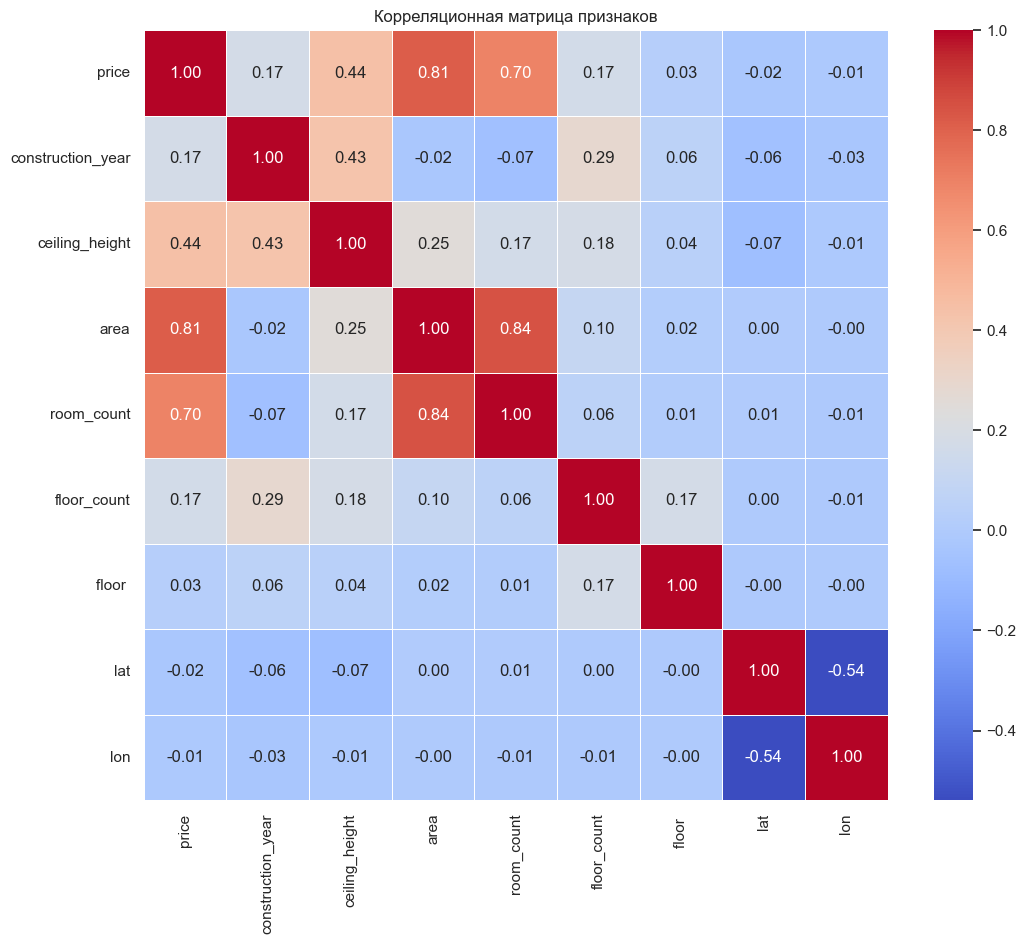

Связь признаков с ценой (price):
price                1.00
area                 0.81
room_count           0.70
ceiling_height       0.44
construction_year    0.17
floor_count          0.17
floor                0.03
lon                 -0.01
lat                 -0.02
Name: price, dtype: float64


In [171]:
# 1. Выбираем только числовые колонки
# Добавим 'distance_to_center', если ты уже его создала
numeric_cols = [
    'price', 'construction_year', 'ceiling_height', 'area', 
    'room_count', 'floor_count', 'floor ', 'lat', 'lon'
]

# Проверяем, какие из этих колонок есть в наличии
existing_numeric_cols = [col for col in numeric_cols if col in df_cleaned.columns]
corr_matrix = df_cleaned[existing_numeric_cols].corr()

# 2. Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,       # Показывает цифры внутри ячеек
    fmt=".2f",        # Округление до 2 знаков
    cmap='coolwarm',  # Цветовая схема: синий (отриц.), красный (полож.)
    linewidths=0.5
)
plt.title("Корреляционная матрица признаков")
plt.show()

# 3. Вывод корреляции конкретно с ценой (в порядке убывания)
print("Связь признаков с ценой (price):")
print(corr_matrix['price'].sort_values(ascending=False))

# 4. Feature Engineering

In [172]:
# 1. Координаты центра (Астана) (район Байтерека)
center_lat = 51.1283
center_lon = 71.4304

def calculate_distance(row):
    """
    Вычисляет расстояние между точкой (lat, lon) и центром 
    по формуле гаверсинусов.
    """
    # Радиус Земли в километрах
    R = 6371.0
    
    # Координаты квартиры
    lat1 = np.radians(row['lat'])
    lon1 = np.radians(row['lon'])
    
    # Координаты центра
    lat2 = np.radians(center_lat)
    lon2 = np.radians(center_lon)
    
    # Разница координат
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Формула гаверсинусов
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    distance = R * c
    return distance

# 2. Применяем функцию к каждой строке датафрейма
df_cleaned['distance_to_center'] = df_cleaned.apply(calculate_distance, axis=1)

print("Признак 'distance_to_center' создан.")
print(df_cleaned[['lat', 'lon', 'distance_to_center']].head())

Признак 'distance_to_center' создан.
    lat   lon  distance_to_center
0 51.08 71.43                5.48
1 51.14 71.39                2.95
2 51.10 71.36                5.65
3 51.12 71.25               12.26
4 51.12 71.44                1.58


In [173]:
df_cleaned['district'].unique()

array(['Есильский р-н', 'Нура р-н', 'Сарайшык р-н', 'Сарыарка р-н',
       'Алматы р-н', 'р-н Байконур'], dtype=object)

In [174]:
df_cleaned['owner'].unique()

array(['Новостройка', 'Риелтор', 'Хозяин недвижимости'], dtype=object)

In [175]:
df_cleaned['house_type'].unique()

array(['монолитный дом', 'кирпичный дом', 'панельный дом'], dtype=object)

In [176]:
from sklearn.preprocessing import OneHotEncoder

# 1. Список колонок для кодирования
# Мы не берем 'url', так как это уникальный идентификатор, а не категория
cat_cols = ['district', 'owner', 'house_type']

# 2. Инициализируем энкодер
# drop='first' помогает избежать мультиколлинеарности (важно для линейных моделей)
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='error')

# 3. Обучаем и трансформируем выбранные колонки
encoded_data = encoder.fit_transform(df_cleaned[cat_cols])

# 4. Создаем имена для новых колонок
encoded_cols = encoder.get_feature_names_out(cat_cols)

# 5. Создаем DataFrame из закодированных данных
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols, index=df_cleaned.index)

# 6. Соединяем с основным датафреймом и удаляем старые текстовые колонки
df_final = pd.concat([df_cleaned, df_encoded], axis=1)
df_final = df_final.drop(columns=cat_cols + ['url','lat', 'lon']) # URL больше не нужен для модели

print(f"Кодирование завершено. Новых колонок добавлено: {len(encoded_cols)}")
print(f"Итоговое количество признаков: {df_final.shape[1]}")

Кодирование завершено. Новых колонок добавлено: 9
Итоговое количество признаков: 17


In [177]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22540 entries, 0 to 22850
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      22540 non-null  float64
 1   construction_year          22540 non-null  int64  
 2   ceiling_height             22540 non-null  float64
 3   area                       22540 non-null  float64
 4   room_count                 22540 non-null  float64
 5   floor_count                22540 non-null  float64
 6   floor                      22540 non-null  float64
 7   distance_to_center         22540 non-null  float64
 8   district_Есильский р-н     22540 non-null  float64
 9   district_Нура р-н          22540 non-null  float64
 10  district_Сарайшык р-н      22540 non-null  float64
 11  district_Сарыарка р-н      22540 non-null  float64
 12  district_р-н Байконур      22540 non-null  float64
 13  owner_Риелтор              22540 non-null  float64


In [178]:
def get_year_category(year):
    if year < 1970:
        return 1  # 1960-е и раньше
    elif 1970 <= year < 1980:
        return 2  # 1970-е
    elif 1980 <= year < 1990:
        return 3  # 1980-е
    elif 1990 <= year < 2000:
        return 4  # 1990-е
    elif 2000 <= year < 2010:
        return 5  # 2000-е
    elif 2010 <= year < 2020:
        return 6  # 2010-е
    elif year >= 2020:
        return 7  # 2020-е
    else:
        return 0

# Применяем функцию к колонке года постройки
# Присваиваем результат новой колонке
df_final['year_category'] = df_final['construction_year'].apply(get_year_category)

# Теперь проверяем оба столбца сразу
print(df_final[['construction_year', 'year_category']].head(10))

   construction_year  year_category
0               2026              7
1               2026              7
2               2026              7
3               2022              7
4               2012              6
5               2025              7
6               2025              7
7               2024              7
8               2026              7
9               2026              7


In [179]:
df_final= df_final.drop(['construction_year'], axis=1)

In [180]:
df_final['price_per_m2'] = df_final['price'] / df_final['area']
df_final['price_per_m2']

0       1043000.00
1        874000.00
2        768000.00
3        290000.00
4        551724.14
           ...    
22846    422222.22
22847    988095.24
22848    556872.04
22849    701978.30
22850    507566.94
Name: price_per_m2, Length: 22540, dtype: float64

In [181]:
df_final = df_final.drop(['price'], axis=1)

In [245]:
df_final.to_csv('new_features_of_krisha_data.csv', index=False)

In [246]:
df_krisha = pd.read_csv('new_features_of_krisha_data.csv')
df_krisha

,ceiling_height,area,room_count,floor_count,floor,distance_to_center,district_Есильский р-н,district_Нура р-н,district_Сарайшык р-н,district_Сарыарка р-н,district_р-н Байконур,owner_Риелтор,owner_Хозяин недвижимости,house_type_монолитный дом,house_type_панельный дом,year_category,price_per_m2
0,3.00,70.38,2.00,11.00,17.00,5.48,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,7,1043000.00
1,3.00,65.97,2.00,13.00,16.00,2.95,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,7,874000.00
2,2.65,48.02,2.00,13.00,17.00,5.65,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,7,768000.00
3,2.70,27.40,1.00,3.00,3.00,12.26,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7,290000.00
4,3.00,87.00,3.00,10.00,6.00,1.58,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,6,551724.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22535,2.50,45.00,2.00,5.00,4.00,4.83,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,1,422222.22
22536,3.30,42.00,2.00,12.00,7.00,2.84,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,7,988095.24
22537,3.00,42.20,1.00,16.00,9.00,5.17,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,7,556872.04
22538,3.00,47.01,2.00,17.00,2.00,4.06,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,7,701978.30


In [235]:
df_krisha['luxury_mask'] = (df_krisha['ceiling_height'] >= 3.0) & (df_krisha['district_Есильский р-н'] == 1)
df_krisha['budget_mask'] = (df_krisha['year_category'] <= 2) | (df_krisha['house_type_панельный дом'] == 1)
df_krisha['middle_mask'] = ~(df_krisha['luxury_mask'] | df_krisha['budget_mask'])

In [197]:
df_krisha['is_high_ceiling'] = (df_krisha['ceiling_height'] >= 3.0).astype(int)

In [200]:
df_krisha = df_krisha.drop(['ceiling_height'], axis=1)

In [206]:
df_krisha['premium_factor'] = df_krisha['is_high_ceiling'] * df_krisha['district_Есильский р-н']

In [211]:
# Если дом старый (year_category низкая) И он панельный
df_krisha['economy_old_panel'] = (df_krisha['year_category'] <= 3) * df_krisha['house_type_панельный дом']

In [215]:
df_krisha['log_distance'] = np.log1p(df_krisha['distance_to_center'])

In [249]:
df_krisha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22540 entries, 0 to 22539
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ceiling_height             22540 non-null  float64
 1   area                       22540 non-null  float64
 2   room_count                 22540 non-null  float64
 3   floor_count                22540 non-null  float64
 4   floor                      22540 non-null  float64
 5   distance_to_center         22540 non-null  float64
 6   district_Есильский р-н     22540 non-null  float64
 7   district_Нура р-н          22540 non-null  float64
 8   district_Сарайшык р-н      22540 non-null  float64
 9   district_Сарыарка р-н      22540 non-null  float64
 10  district_р-н Байконур      22540 non-null  float64
 11  owner_Риелтор              22540 non-null  float64
 12  owner_Хозяин недвижимости  22540 non-null  float64
 13  house_type_монолитный дом  22540 non-null  flo

In [248]:
df_krisha['area_per_room'] = df_krisha['area'] / df_krisha['room_count']

In [257]:
df = df_krisha.copy()

# Log transform target (most impactful)
y = np.log1p(df['price_per_m2'])

# Floor position features
df['floor_ratio'] = df['floor '] / df['floor_count']
df['is_top_floor'] = (df['floor '] == df['floor_count']).astype(int)
df['is_ground_floor'] = (df['floor '] == 1).astype(int)

# Log transforms for skewed features
df['log_area'] = np.log1p(df['area'])
df['log_distance'] = np.log1p(df['distance_to_center'])
df['area_squared']   = df['area'] ** 2 

# Interaction terms
df['area_x_rooms'] = df['area'] * df['room_count']
df['distance_x_district_esilsky'] = df['distance_to_center'] * df['district_Есильский р-н']

In [241]:
df_krisha = df_krisha.drop(['floor_count', 'floor ', 'ceiling_height', 'room_count', 'area'], axis=1)

In [122]:
def remove_outliers(df):
    initial_shape = df.shape[0]
    
    # 2. Цена за квадрат (чтобы убрать ошибки ввода типа 100 тенге или 10 млн)
    # Ориентируемся на рынок Астаны: (примерно от 200к до 1.5 млн)
    df = df[(df['price_per_m2'] >= 400_000) & (df['price_per_m2'] <= 1_500_000)]
    
    # 3. Высота потолков (убираем 20 метров или 1 метр)
    df = df[(df['ceiling_height'] >= 2.5) & (df['ceiling_height'] <= 4.0)]
    
    # 5. Комнаты
    if 'room_count' in df.columns:
        df = df[(df['room_count'] >= 1) & (df['room_count'] <= 5)]
    
    # 6. Этажность
    df = df[(df['floor_count'] >= 1) & (df['floor_count'] <= 27)]
    
    final_shape = df.shape[0]
    print(f"Удалено аномалий: {initial_shape - final_shape} строк")
    print(f"Осталось данных: {final_shape} строк")
    
    return df

# Применяем функцию
df_krisha = remove_outliers(df_krisha)

Удалено аномалий: 1497 строк
Осталось данных: 21043 строк


In [261]:
df_krisha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22540 entries, 0 to 22539
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ceiling_height             22540 non-null  float64
 1   area                       22540 non-null  float64
 2   room_count                 22540 non-null  float64
 3   floor_count                22540 non-null  float64
 4   floor                      22540 non-null  float64
 5   distance_to_center         22540 non-null  float64
 6   district_Есильский р-н     22540 non-null  float64
 7   district_Нура р-н          22540 non-null  float64
 8   district_Сарайшык р-н      22540 non-null  float64
 9   district_Сарыарка р-н      22540 non-null  float64
 10  district_р-н Байконур      22540 non-null  float64
 11  owner_Риелтор              22540 non-null  float64
 12  owner_Хозяин недвижимости  22540 non-null  float64
 13  house_type_монолитный дом  22540 non-null  flo

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22540 entries, 0 to 22539
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ceiling_height               22540 non-null  float64
 1   area                         22540 non-null  float64
 2   room_count                   22540 non-null  float64
 3   floor_count                  22540 non-null  float64
 4   floor                        22540 non-null  float64
 5   distance_to_center           22540 non-null  float64
 6   district_Есильский р-н       22540 non-null  float64
 7   district_Нура р-н            22540 non-null  float64
 8   district_Сарайшык р-н        22540 non-null  float64
 9   district_Сарыарка р-н        22540 non-null  float64
 10  district_р-н Байконур        22540 non-null  float64
 11  owner_Риелтор                22540 non-null  float64
 12  owner_Хозяин недвижимости    22540 non-null  float64
 13  house_type_монол

# 5. Обучение модели (Linear Regression)

### Разделение датасета на X и y
### X = price
### y = остальные признаки датасета

In [264]:
y = np.log1p(df['price_per_m2'])  # лог от цены
X = df.drop(columns=['price_per_m2'])

# 3. Проверка размерности
print(f"Размер признаков (X): {X.shape}")
print(f"Размер целевой переменной (y): {y.shape}")

Размер признаков (X): (22540, 25)
Размер целевой переменной (y): (22540,)


In [268]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Разделяем на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Создаем скалер
scaler = StandardScaler()

# 3. Обучаем скалер ТОЛЬКО на train и трансформируем оба набора
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучаем модель
model = LinearRegression()





model.fit(X_train_scaled, y_train)

# 5. Делаем предсказание
y_pred_log = model.predict(X_test_scaled)  # предсказание в log-шкале
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print(f"R2 Score (log): {r2_score(y_test, y_pred_log):.4f}")       # для сравнения моделей
print(f"R2 Score (real): {r2_score(y_test_real, y_pred_real):.4f}") # реальный R²
print(f"MAE: {mean_absolute_error(y_test_real, y_pred_real):,.0f} тенге")

R2 Score (log): 0.5359
R2 Score (real): 0.5073
MAE: 98,217 тенге


# 6. Оценка результатов

In [226]:
# Создаем таблицу для сравнения
comparison_df = pd.DataFrame({
    'Реальная цена': y_test.values,
    'Предсказанная цена': y_pred
})

# Добавляем колонку разницы (ошибки)
comparison_df['Разница'] = comparison_df['Реальная цена'] - comparison_df['Предсказанная цена']
comparison_df['Ошибка %'] = (abs(comparison_df['Разница']) / comparison_df['Реальная цена']) * 100

# Выводим первые 10 строк
print(comparison_df.head(10).round(0))

   Реальная цена  Предсказанная цена    Разница  Ошибка %
0      800000.00           770487.00   29513.00      4.00
1      506836.00           435189.00   71646.00     14.00
2      628205.00           507421.00  120784.00     19.00
3      695000.00           881431.00 -186431.00     27.00
4      486111.00           691312.00 -205201.00     42.00
5     1013645.00           803758.00  209887.00     21.00
6      413953.00           607526.00 -193573.00     47.00
7      800000.00           710415.00   89585.00     11.00
8      974359.00           791165.00  183194.00     19.00
9      565217.00           778831.00 -213614.00     38.00


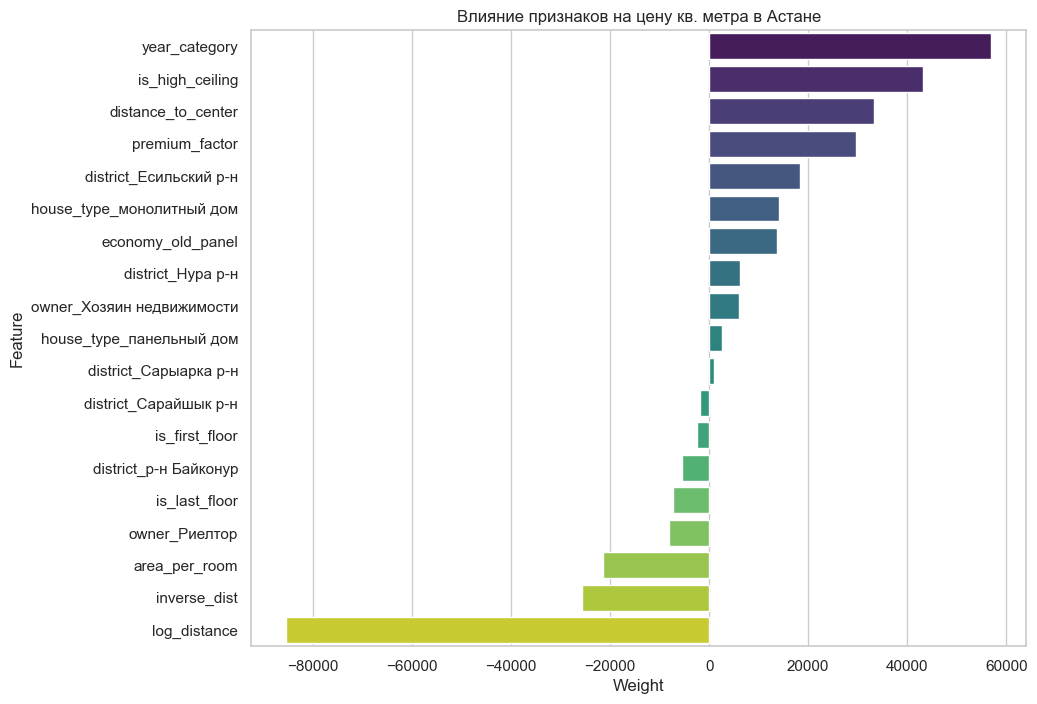

In [227]:
# Получаем коэффициенты
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
})

# Сортируем по силе влияния
coefficients = coefficients.sort_values(by='Weight', ascending=False)

# Визуализация
plt.figure(figsize=(10, 8))
sns.barplot(x='Weight', y='Feature', data=coefficients, palette='viridis')
plt.title('Влияние признаков на цену кв. метра в Астане')
plt.show()

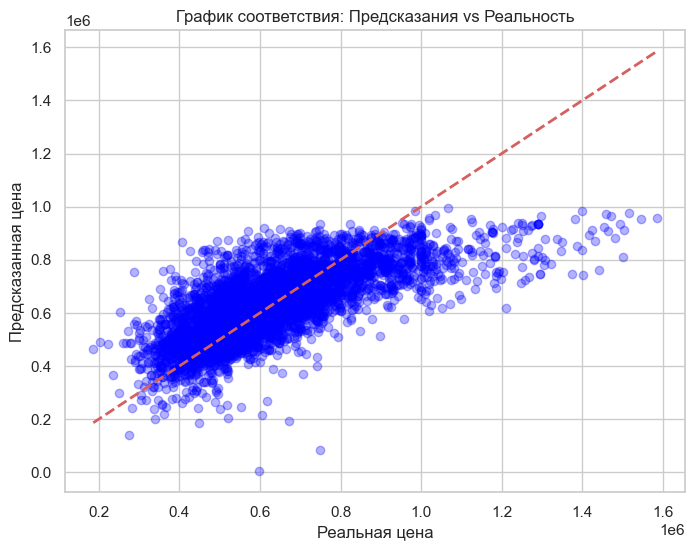

In [228]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('График соответствия: Предсказания vs Реальность')
plt.show()